# Poisson Regression

## Overview

Poisson regression models count outcomes (non-negative integers). The response is modelled on the log scale, so coefficients are log rate ratios — exponentiate to get rate ratios.

**When to use Poisson:**
- Outcome is a count (species abundance, events per site, detections per survey)
- Counts are rare enough that variance roughly equals the mean

**Key diagnostics:**
- Overdispersion: var >> mean → use Negative Binomial or quasi-Poisson
- Excess zeros: many more zeros than Poisson predicts → use Zero-Inflated Poisson
- Offset: when counts come from sampling efforts of different sizes, include `log(effort)` as an offset

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

rng = np.random.default_rng(42)
n = 180
elevation = rng.uniform(50, 400, n)
nitrate   = rng.gamma(2, 2, n)
treatment = rng.choice([0,1], n)
effort    = rng.uniform(0.5, 2.0, n)  # survey hours -- variable sampling effort
# True log rate: counts per unit effort
log_mu = np.log(effort) + 1.8 - 0.003*elevation - 0.1*nitrate + 0.4*treatment
counts = rng.poisson(np.exp(log_mu))
df = pd.DataFrame({"counts":counts,"elevation":elevation,"nitrate":nitrate,
                   "treatment":treatment,"effort":effort})
print(f"Count summary: mean={counts.mean():.2f}, var={counts.var():.2f}, max={counts.max()}")
print(f"Var/Mean ratio: {counts.var()/counts.mean():.2f}  (1.0 = equidispersion)")

Count summary: mean=3.41, var=6.63, max=12
Var/Mean ratio: 1.94  (1.0 = equidispersion)


---
## Fitting Poisson Regression with Offset

In [2]:
X = sm.add_constant(df[["elevation","nitrate","treatment"]])
model = sm.GLM(df["counts"], X,
               family=sm.families.Poisson(),
               offset=np.log(df["effort"])).fit()
print(model.summary())
# Rate ratios
rr_df = pd.DataFrame({
    "RR":   np.exp(model.params),
    "CI_lo":np.exp(model.conf_int()[0]),
    "CI_hi":np.exp(model.conf_int()[1])
})
print("\nRate Ratios:")
print(rr_df.round(3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 counts   No. Observations:                  180
Model:                            GLM   Df Residuals:                      176
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -337.92
Date:                Wed, 18 Mar 2026   Deviance:                       190.87
Time:                        20:42:38   Pearson chi2:                     177.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4053
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7753      0.125     14.229      0.0

---
## Overdispersion Check

Pearson chi2/df = 1.006  (>1.5 suggests overdispersion)


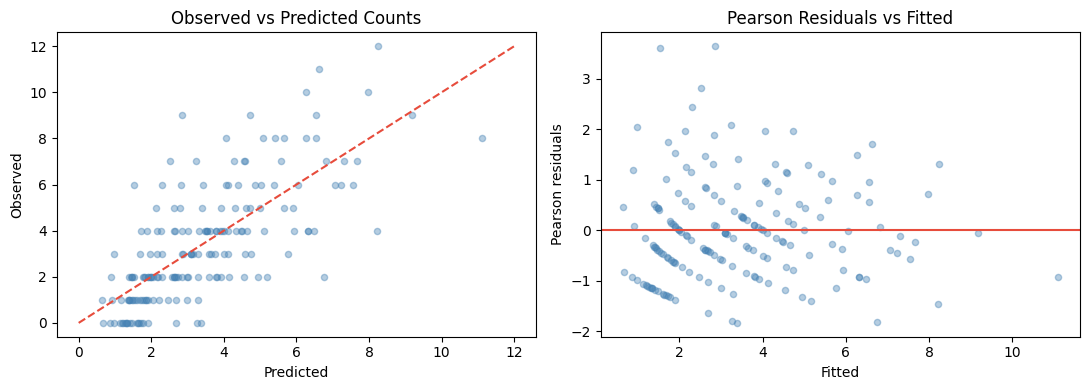

In [3]:
# Pearson chi-squared / df should be ~1 for equidispersion
pearson_chi2 = ((df["counts"] - model.predict())**2 / model.predict()).sum()
df_resid = model.df_resid
disp = pearson_chi2 / df_resid
print(f"Pearson chi2/df = {disp:.3f}  (>1.5 suggests overdispersion)")

# Plot observed vs predicted counts
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(model.predict(), df["counts"], alpha=0.4, s=20, color="steelblue")
axes[0].plot([0,df["counts"].max()],[0,df["counts"].max()],"--",color="#e74c3c",lw=1.5)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Observed")
axes[0].set_title("Observed vs Predicted Counts")
# Residuals vs fitted
resid_pearson = model.resid_pearson
axes[1].scatter(model.predict(), resid_pearson, alpha=0.4, s=20, color="steelblue")
axes[1].axhline(0, color="#e74c3c", lw=1.5)
axes[1].set_xlabel("Fitted"); axes[1].set_ylabel("Pearson residuals")
axes[1].set_title("Pearson Residuals vs Fitted")
plt.tight_layout(); plt.show()

---
## Quasi-Poisson for Overdispersed Counts

In [4]:
# Quasi-Poisson: same point estimates, corrected (inflated) SEs
model_qp = sm.GLM(df["counts"], X,
                  family=sm.families.Poisson(),
                  offset=np.log(df["effort"])).fit(cov_type="HC3")
print("Comparison of SEs -- Poisson vs Quasi-Poisson:")
se_compare = pd.DataFrame({
    "Poisson SE":    model.bse,
    "QuasiPoisson SE": model_qp.bse
}).round(4)
print(se_compare)
print("\nIf overdispersion is present, quasi-Poisson SEs are wider and more honest.")

Comparison of SEs -- Poisson vs Quasi-Poisson:
           Poisson SE  QuasiPoisson SE
const          0.1248           0.1140
elevation      0.0004           0.0004
nitrate        0.0158           0.0153
treatment      0.0844           0.0849

If overdispersion is present, quasi-Poisson SEs are wider and more honest.


---

## Common Pitfalls

**1. Fitting Poisson regression without checking for overdispersion**  
Overdispersion (var >> mean) makes Poisson SEs too small, producing falsely narrow CIs and inflated significance. Always compute Pearson chi-squared / df after fitting. If > 1.5, use quasi-Poisson or Negative Binomial.

**2. Omitting the offset for variable sampling effort**  
If survey duration, area, or sampling effort varies across sites, raw counts are not comparable. Always include `log(effort)` as an offset. Omitting it confounds effort variation with covariate effects.

**3. Interpreting Poisson coefficients on the log scale directly**  
Poisson coefficients are log rate ratios. A coefficient of 0.4 means a 49% increase in rate (exp(0.4)=1.49), not a 0.4-unit increase in counts. Always exponentiate and report as rate ratios with CIs.

**4. Not checking for excess zeros**  
If observed zeros substantially exceed what the Poisson distribution predicts, a Zero-Inflated Poisson (ZIP) model is more appropriate. Plot observed vs Poisson-predicted zero frequency as a diagnostic.

**5. Using Poisson regression for bounded counts or proportions**  
Poisson assumes counts can be arbitrarily large. For bounded counts (e.g. 0-10 individuals out of 10 sampled) use Binomial regression. For continuous proportions use Beta regression.

---
*python_methods_library - Samantha McGarrigle*